# 05 — CD4 T cell extraction and sub-clustering
Input: annotated object (04). CD4 compartment = CD4 memory + CD4 naive/CM + Treg (24,455 cells).
Paper: CD4 clusters subset, re-clustered and annotated into naive/CM, Teff, TEMRA, Treg (Fig 5a–b).

## Step 11.1 — Setup and load the annotated object

In [1]:
suppressPackageStartupMessages({
  library(Seurat); library(tidyverse); library(patchwork)
})
proj <- "/mnt/d/project3_IFN-I"
set.seed(42)
options(future.globals.maxSize = Inf)
m <- "rpca"

obj <- readRDS(file.path(proj, "results/objects", paste0("04_annotated_", m, ".rds")))
table(obj$celltype)


            B cells      CD14 monocytes      CD16 monocytes          CD4 memory 
               8626               24806                3505               12787 
       CD4 naive/CM CD8 effector memory           CD8 naive                cDC2 
               9755               12881                2195                 900 
        Low quality                MAIT            NK cells                 pDC 
               2721                1217                8383                  92 
          Platelets       Proliferating                Treg 
                453                 268                1913 

## Step 11.2 — Check: are CD4 TEMRA cells hiding in the CD8 effector cluster?


In [2]:
cnt <- LayerData(obj, assay = "RNA", layer = "counts")
det <- as.matrix(t(cnt[c("CD4", "CD8A", "CD8B"), ] > 0))
rm(cnt); invisible(gc())

t_types <- c("CD4 naive/CM", "CD4 memory", "Treg", "CD8 naive", "CD8 effector memory")

cd4_cd8_check <- obj@meta.data |>
  mutate(CD4 = det[, "CD4"], CD8 = det[, "CD8A"] | det[, "CD8B"]) |>
  filter(celltype %in% t_types) |>
  group_by(celltype) |>
  summarise(n_cells       = n(),
            pct_CD4_only  = round(100 * mean(CD4 & !CD8), 1),
            pct_CD8_only  = round(100 * mean(CD8 & !CD4), 1),
            pct_both      = round(100 * mean(CD4 & CD8), 1),
            pct_neither   = round(100 * mean(!CD4 & !CD8), 1),
            .groups = "drop")
cd4_cd8_check
write_csv(cd4_cd8_check, file.path(proj, "results/tables/05_cd4_cd8_detection.csv"))

celltype,n_cells,pct_CD4_only,pct_CD8_only,pct_both,pct_neither
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
CD4 memory,12787,25.8,6.8,1.0,66.3
CD4 naive/CM,9755,21.9,2.5,0.4,75.1
CD8 effector memory,12881,4.6,56.1,1.6,37.7
CD8 naive,2195,1.1,63.4,1.3,34.2
Treg,1913,21.5,3.8,0.9,73.8


### CD4/CD8 detection check
- CD4 transcript detected in only 22–26% of true CD4 cells (snRNA dropout) -> compare to baselines.
- CD8 effector memory: 4.6% CD4-only vs 1.1% baseline (CD8 naive) -> est. ~15–17% CD4 cells
  (~2,000), likely cytotoxic CD4 TEMRA. Not rescued (follows paper: CD4 clusters only);
  TEMRA subset may be under-represented.
- CD4 memory: 6.8% CD8-only vs 2.5% baseline (CD4 naive) -> est. ~5–7% CD8 contamination;
  check CD8A/CD8B across CD4 sub-clusters.

## Step 11.3 — Extract the CD4 T cells

In [3]:
cd4 <- subset(obj, subset = celltype %in% c("CD4 naive/CM", "CD4 memory", "Treg"))
rm(obj); invisible(gc())
cd4
table(cd4$sample, cd4$celltype)

An object of class Seurat 
36601 features across 24455 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 2 layers present: data, counts
 4 dimensional reductions calculated: pca, umap.unintegrated, integrated.rpca, umap.rpca

     
      CD4 memory CD4 naive/CM Treg
  HD1       1595         1383  118
  HD2       1190          240  125
  P1        1216          298  234
  P2        2522         1570  425
  P3        1905          956  279
  P4         669          862  141
  P5         485          750   53
  P6        1101          663  145
  P7        1318         1350  239
  P8         786         1683  154

## Step 11.4 — Re-process the CD4 subset: variable genes, scale, PCA

Splitting ‘counts’, ‘data’ layers. Not splitting . If you would like to split other layers, set in `layers` argument.

Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -2.9222”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 0.30103”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  3.4447e-16”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -2.8089”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 0.30103”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  2.0962e-15”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -2.9798”
Warning mes

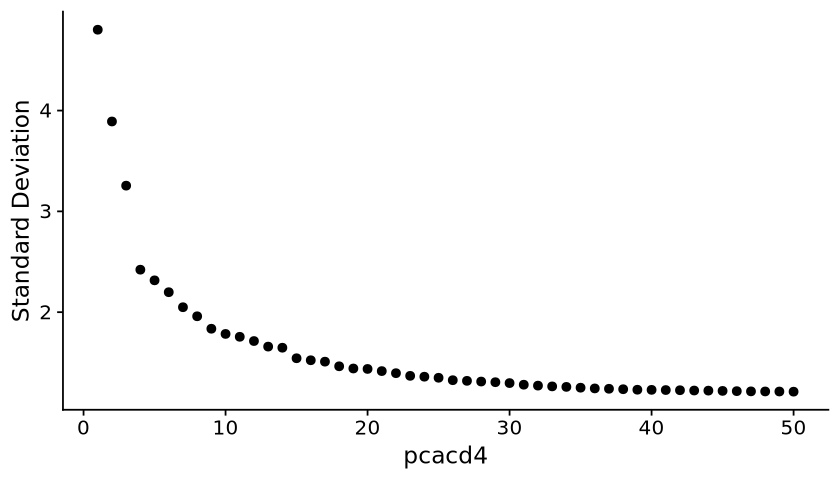

In [4]:
cd4[["RNA"]] <- split(cd4[["RNA"]], f = cd4$sample)
cd4 <- FindVariableFeatures(cd4, nfeatures = 2000, verbose = FALSE)
cd4 <- ScaleData(cd4, verbose = FALSE)
cd4 <- RunPCA(cd4, npcs = 50, reduction.name = "pca_cd4", verbose = FALSE)

options(repr.plot.width = 7, repr.plot.height = 4)
elbow_cd4 <- ElbowPlot(cd4, ndims = 50, reduction = "pca_cd4")
elbow_cd4
ggsave(file.path(proj, "figures/trackB/05_elbow_cd4.png"), elbow_cd4, width = 7, height = 4, dpi = 150)

### CD4 PC selection
- Elbow: steep PCs 1–4, gradual to ~15, flat from ~20–25. Using 20 PCs for CD4 integration,
  clustering and UMAP (paper does not report this).

## Step 11.5 — Integrate CD4 cells and cluster at several resolutions

In [5]:
dims_cd4 <- 1:20

cd4 <- IntegrateLayers(cd4, method = RPCAIntegration, orig.reduction = "pca_cd4",
                       new.reduction = "integrated_cd4", verbose = FALSE)
cd4 <- FindNeighbors(cd4, reduction = "integrated_cd4", dims = dims_cd4, verbose = FALSE)
for (r in c(0.3, 0.5, 0.8)) {
  cd4 <- FindClusters(cd4, resolution = r, cluster.name = paste0("cd4_res", r), verbose = FALSE)
}
cd4 <- RunUMAP(cd4, reduction = "integrated_cd4", dims = dims_cd4,
               reduction.name = "umap_cd4", verbose = FALSE)

cd4[["RNA"]]$scale.data <- NULL
cd4 <- JoinLayers(cd4)

sapply(c("cd4_res0.3", "cd4_res0.5", "cd4_res0.8"),
       function(x) length(unique(cd4[[x]][[1]])))

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


cd4_res0.3 cd4_res0.5 cd4_res0.8 
         8         11         13

## Step 11.6 — CD4 UMAPs: by sample, previous label, and each resolution

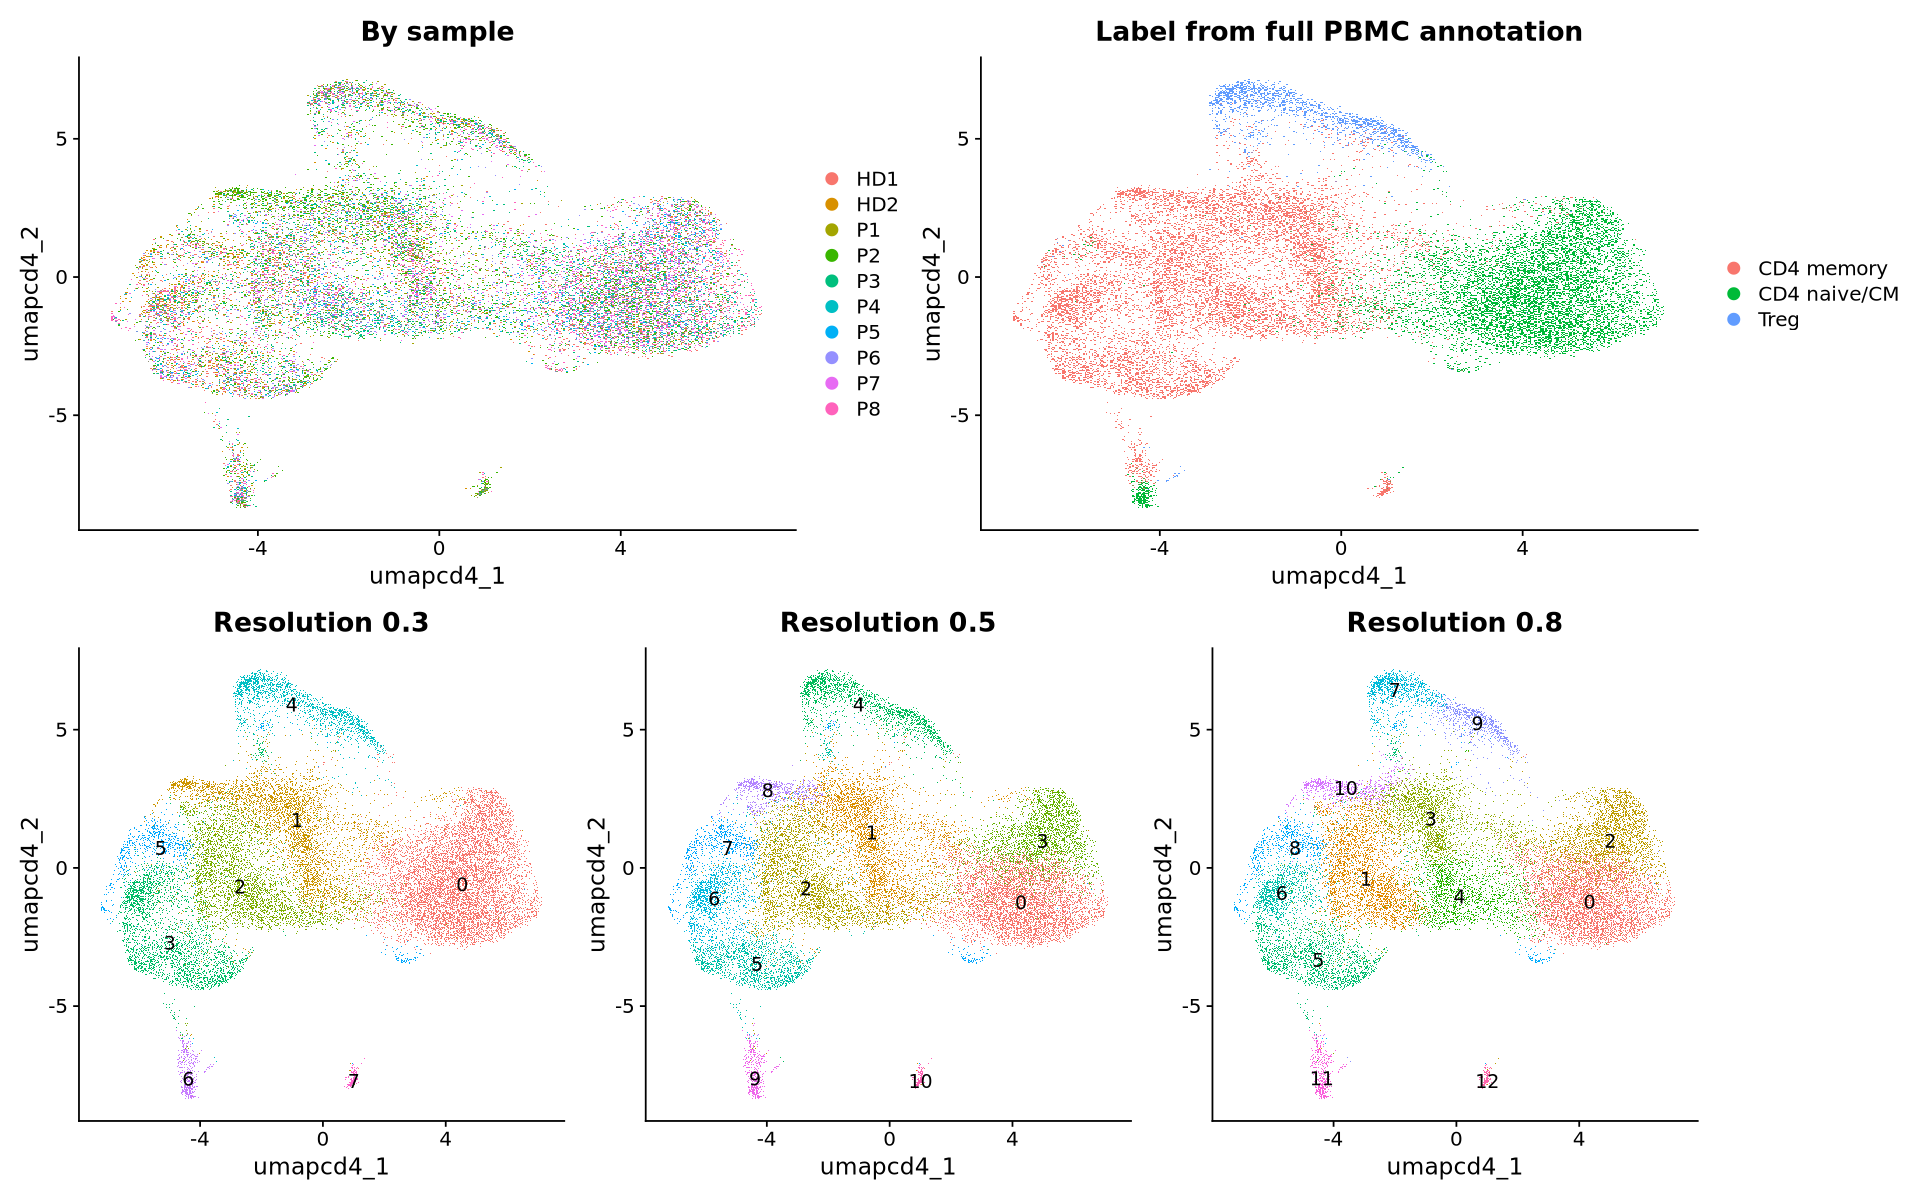

In [6]:
options(repr.plot.width = 16, repr.plot.height = 10)
p_cd4 <- (DimPlot(cd4, reduction = "umap_cd4", group.by = "sample", raster = TRUE) +
            ggtitle("By sample") |
          DimPlot(cd4, reduction = "umap_cd4", group.by = "celltype", raster = TRUE) +
            ggtitle("Label from full PBMC annotation")) /
         (DimPlot(cd4, reduction = "umap_cd4", group.by = "cd4_res0.3", label = TRUE, raster = TRUE) +
            NoLegend() + ggtitle("Resolution 0.3") |
          DimPlot(cd4, reduction = "umap_cd4", group.by = "cd4_res0.5", label = TRUE, raster = TRUE) +
            NoLegend() + ggtitle("Resolution 0.5") |
          DimPlot(cd4, reduction = "umap_cd4", group.by = "cd4_res0.8", label = TRUE, raster = TRUE) +
            NoLegend() + ggtitle("Resolution 0.8"))
p_cd4
ggsave(file.path(proj, "figures/trackB/05_umap_cd4_resolutions.png"), p_cd4,
       width = 16, height = 10, dpi = 150)

## Step 11.7 — Paper's CD4 subset markers across sub-clusters

   
     HD1  HD2   P1   P2   P3   P4   P5   P6   P7   P8
  0 1274  214  260 1410  888  778  663  601 1254 1520
  1  441  279  523 1424  463  235  179  315  407  344
  2  471  268  370  474  851  289  177  435  527  219
  3  558  457  217  463  485  129  150  316  387  201
  4  122  121  233  425  284  155   55  152  241  165
  5  160  178   72  149   91   32   30   61   35   91
  6   66   35   34  100   69   50   23   24   47   64
  7    4    3   39   72    9    4   11    5    9   19

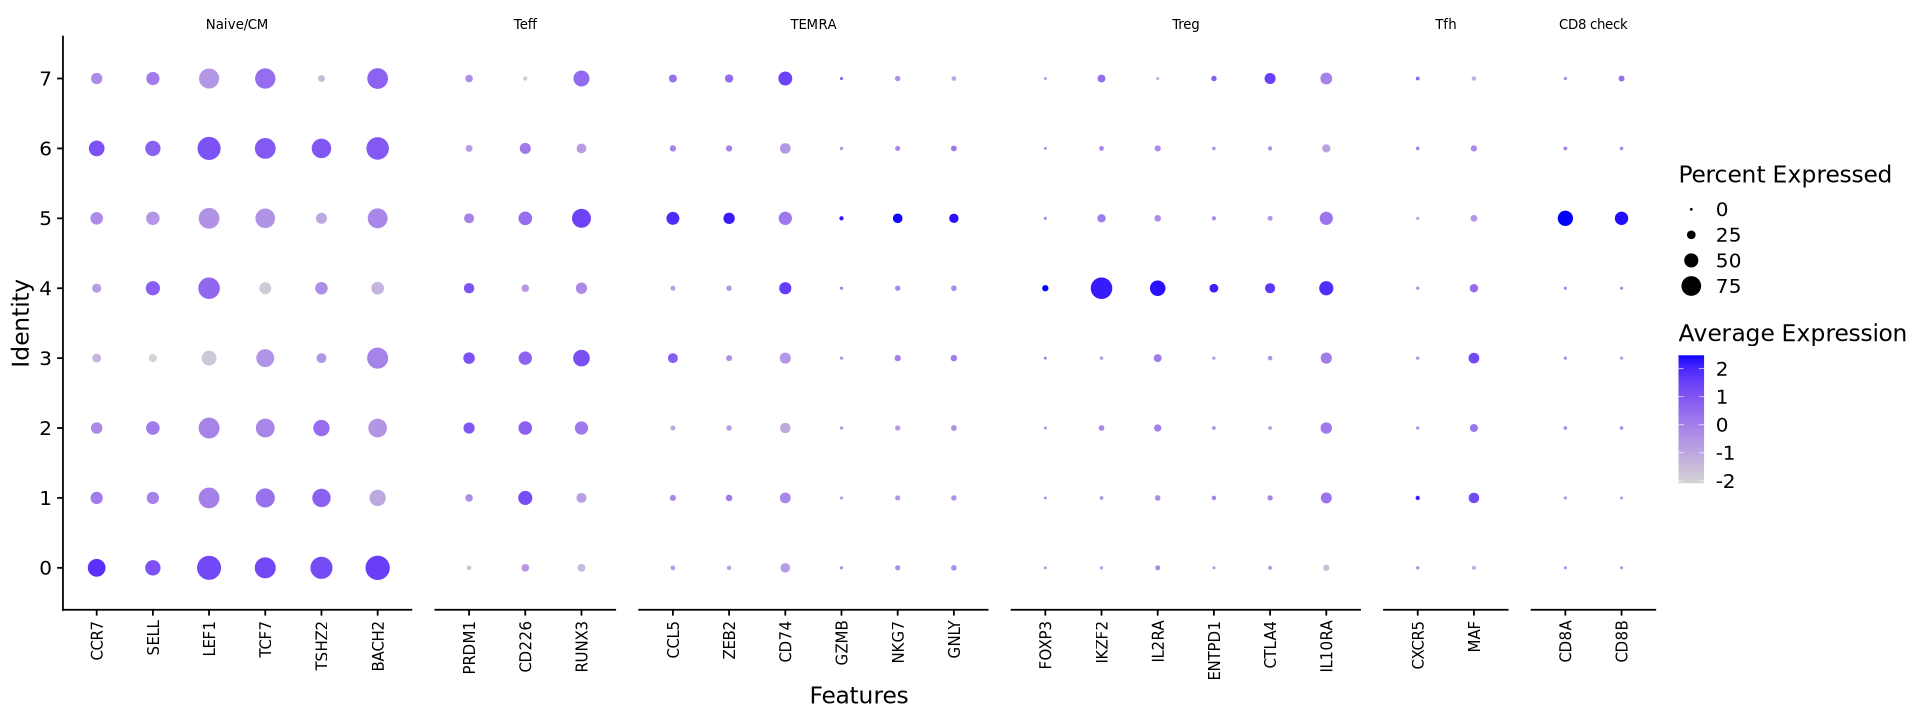

In [7]:
res_use <- "cd4_res0.3"
Idents(cd4) <- res_use

cd4_markers <- list(
  "Naive/CM" = c("CCR7", "SELL", "LEF1", "TCF7", "TSHZ2", "BACH2"),
  "Teff"     = c("PRDM1", "CD226", "RUNX3"),
  "TEMRA"    = c("CCL5", "ZEB2", "CD74", "GZMB", "NKG7", "GNLY"),
  "Treg"     = c("FOXP3", "IKZF2", "IL2RA", "ENTPD1", "CTLA4", "IL10RA"),
  "Tfh"      = c("CXCR5", "MAF"),
  "CD8 check"= c("CD8A", "CD8B")
)

options(repr.plot.width = 16, repr.plot.height = 6)
dp_cd4 <- DotPlot(cd4, features = cd4_markers) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 9),
        strip.text.x = element_text(size = 8))
dp_cd4
ggsave(file.path(proj, "figures/trackB", paste0("05_cd4_markers_", res_use, ".png")),
       dp_cd4, width = 16, height = 6, dpi = 150)

table(Idents(cd4), cd4$sample)

## Step 11.8 — Checkpoint: save the CD4 object

In [8]:
saveRDS(cd4, file.path(proj, "results/objects/05_cd4_subclustered.rds"), compress = FALSE)

## Step 11.9 — Check clusters 6 and 7: QC metrics and non-T cell markers

cluster,n_cells,median_genes,median_umi,median_mt
<fct>,<int>,<dbl>,<dbl>,<dbl>
0,8862,1653.0,3299.0,6.82
1,4610,1868.5,3853.0,5.83
2,4081,1957.0,4165.0,5.89
3,3363,1941.0,4117.0,6.63
4,1953,1752.0,3523.0,4.92
5,899,2243.0,5014.0,6.15
6,512,1833.0,3872.5,5.99
7,175,2018.0,4345.0,5.92


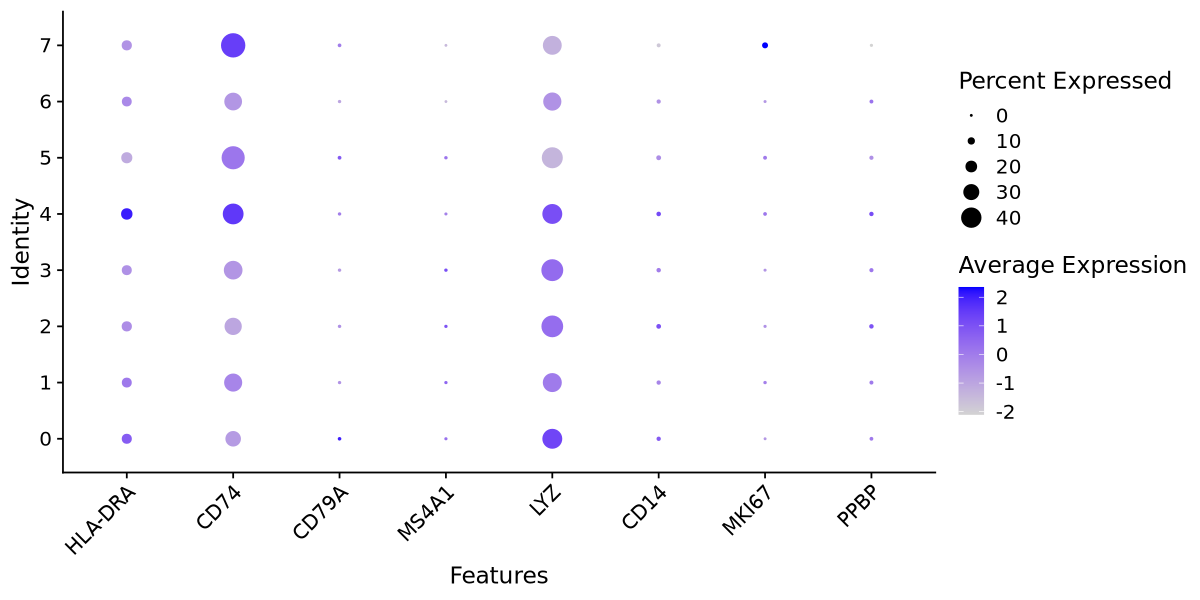

In [11]:
qc_cd4 <- cd4@meta.data |>
  group_by(cluster = cd4_res0.3) |>
  summarise(n_cells      = n(),
            median_genes = median(nFeature_RNA),
            median_umi   = median(nCount_RNA),
            median_mt    = round(median(percent.mt), 2),
            .groups = "drop")
qc_cd4

options(repr.plot.width = 10, repr.plot.height = 5)
dp_check <- DotPlot(cd4, features = c("HLA-DRA", "CD74", "CD79A", "MS4A1", "LYZ", "CD14", "MKI67", "PPBP")) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))
dp_check
ggsave(file.path(proj, "figures/trackB/05_cd4_nonT_check.png"), dp_check, width = 10, height = 5, dpi = 150)

In [12]:
cd4_by_sample <- table(cd4$cd4_res0.3, cd4$sample)
cd4_by_sample
write.csv(as.data.frame.matrix(cd4_by_sample),
          file.path(proj, "results/tables/05_cd4_res0.3_by_sample.csv"))

   
     HD1  HD2   P1   P2   P3   P4   P5   P6   P7   P8
  0 1274  214  260 1410  888  778  663  601 1254 1520
  1  441  279  523 1424  463  235  179  315  407  344
  2  471  268  370  474  851  289  177  435  527  219
  3  558  457  217  463  485  129  150  316  387  201
  4  122  121  233  425  284  155   55  152  241  165
  5  160  178   72  149   91   32   30   61   35   91
  6   66   35   34  100   69   50   23   24   47   64
  7    4    3   39   72    9    4   11    5    9   19

### CD4 subset assignment (resolution 0.3)
- Teff = clusters 2 + 3 (PRDM1, CD226, RUNX3; reduced naive markers).
  Patients only: high IRC 3,278, low IRC 2,412 (ratio 1.36) vs paper 2,305 / 1,643 (ratio 1.40).
  Including cluster 1 would give 9,580 cells (ratio 1.62) -> cluster 1 treated as central memory.
- Teff per patient: P1 587, P2 937, P3 1,336, P4 418, P5 327, P6 751, P7 914, P8 420.
- Cluster 5 = CD8 cytotoxic contamination (CD8A/CD8B+) -> exclude.
- Clusters 6 and 7: no B-cell/monocyte markers (CD79A, MS4A1, CD14 ~0) -> not doublets.
  LYZ at low level in all clusters = ambient RNA.
- Cluster 6 (512): naive markers, normal QC, all samples -> Naive/CM.
- Cluster 7 (175): CD74-high, some MKI67 and CTLA4, P1/P2-enriched -> activated state; excluded.
- Final: Naive/CM (0, 1, 6), Teff (2, 3), Treg (4); excluded CD8 contamination (5) and cluster 7.
  TEMRA not recovered as a separate subset (limitation).

## Step 11.10 — Assign CD4 subsets

In [13]:
subset_map <- c("0" = "Naive/CM", "1" = "Naive/CM", "6" = "Naive/CM",
                "2" = "Teff",     "3" = "Teff",
                "4" = "Treg",
                "5" = "CD8 contamination",
                "7" = "Other (CD74hi)")

cd4$cd4_subset <- unname(subset_map[as.character(cd4$cd4_res0.3)])
table(cd4$cd4_subset, cd4$sample)

                   
                     HD1  HD2   P1   P2   P3   P4   P5   P6   P7   P8
  CD8 contamination  160  178   72  149   91   32   30   61   35   91
  Naive/CM          1781  528  817 2934 1420 1063  865  940 1708 1928
  Other (CD74hi)       4    3   39   72    9    4   11    5    9   19
  Teff              1029  725  587  937 1336  418  327  751  914  420
  Treg               122  121  233  425  284  155   55  152  241  165

## Step 11.11 — CD4 subset UMAP (our version of Fig 5a)

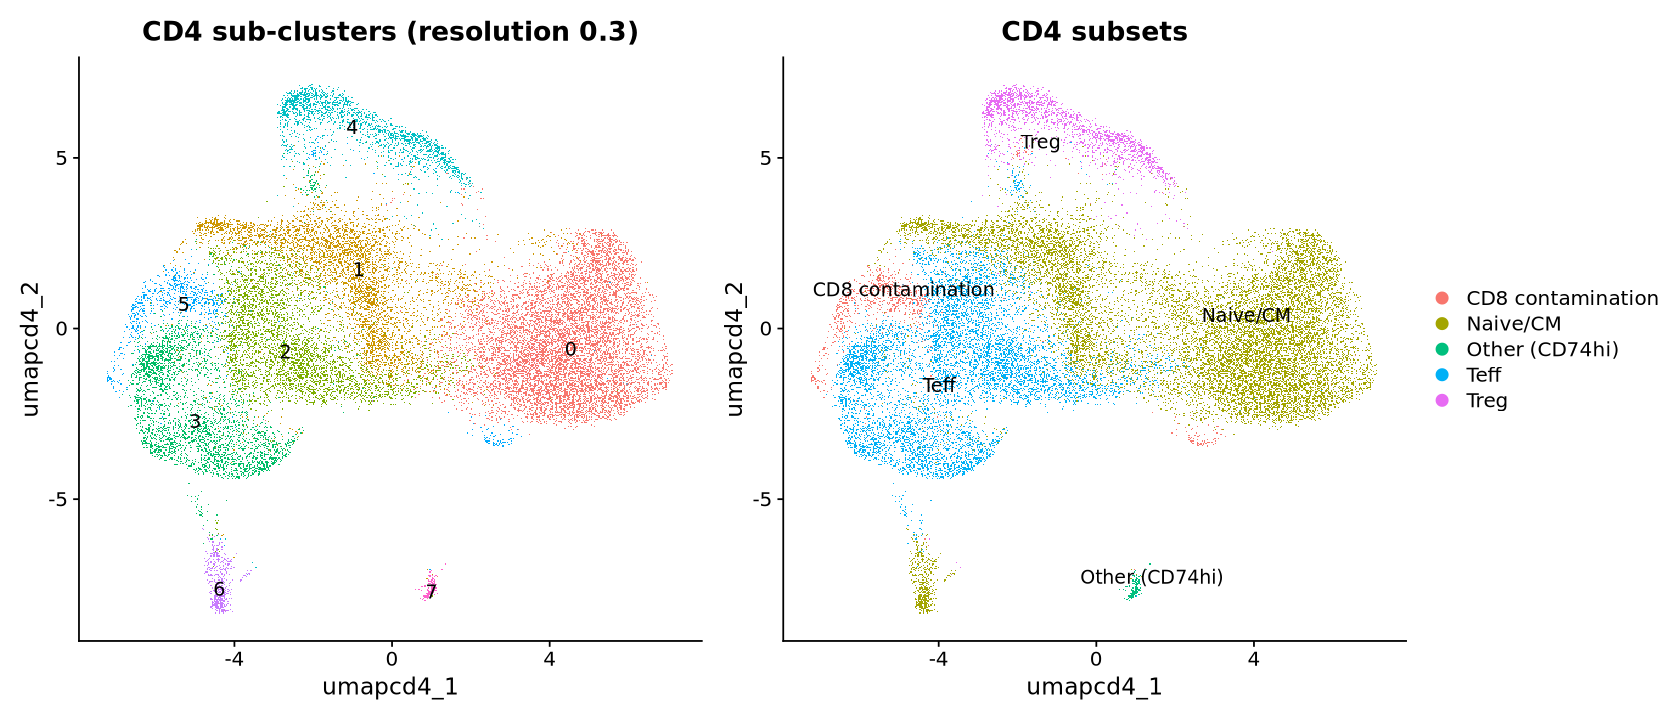

In [14]:
options(repr.plot.width = 14, repr.plot.height = 6)
p_sub <- DimPlot(cd4, reduction = "umap_cd4", group.by = "cd4_res0.3", label = TRUE, raster = TRUE) +
           NoLegend() + ggtitle("CD4 sub-clusters (resolution 0.3)") |
         DimPlot(cd4, reduction = "umap_cd4", group.by = "cd4_subset", label = TRUE,
                 repel = TRUE, raster = TRUE) + ggtitle("CD4 subsets")
p_sub
ggsave(file.path(proj, "figures/trackB/05_umap_cd4_subsets.png"), p_sub, width = 14, height = 6, dpi = 150)

## Step 11.12 — Remove excluded cells and save the clean CD4 object

In [15]:
cd4_clean <- subset(cd4, subset = cd4_subset %in% c("Naive/CM", "Teff", "Treg"))
cd4_clean
table(cd4_clean$cd4_subset, cd4_clean$group)
saveRDS(cd4_clean, file.path(proj, "results/objects/05_cd4_clean.rds"), compress = FALSE)

An object of class Seurat 
36601 features across 23381 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 2 layers present: data, counts
 7 dimensional reductions calculated: pca, umap.unintegrated, integrated.rpca, umap.rpca, pca_cd4, integrated_cd4, umap_cd4

          
             HD high_IRC low_IRC
  Naive/CM 2309     6234    5441
  Teff     1754     3278    2412
  Treg      243     1097     613

### Final CD4 object
- 23,381 cells: Naive/CM 13,984; Teff 7,444; Treg 1,953.
- Teff by group: HD 1,754; high IRC 3,278; low IRC 2,412.
- Treg fraction: HD 6%, high IRC 10%, low IRC 7% (P2 contributes 425 Tregs; not a paper claim).